# Free JJ conserved-current correlators (L=2, Nt=128)

L=2 counterpart of `jj_free_correlators_claude.ipynb` (L=1) — same panels, for side-by-side viewing.
At L=2 only `local` (ultralocal $\hat e\cdot\sigma$ current + lattice $P$) is available; `exact` (basis loop)
is L=1-only and `cont` (continuum $G$) was not run, so those curves are simply absent here.

CFT (Eq. 4.31/4.28): $G_t=-C_J f$, $G_s=(D-1)C_J f$, ratio $G_s/G_t=-(D-1)=-2$.

In [1]:
import h5py, numpy as np, matplotlib.pyplot as plt, os

ESN = "data_free_vmRe0.000000vmIm0.000000"
L   = 2
FILES = {
    "exact" : f"{ESN}/corr_deter_exact_L{L}/corr.0.h5",
    "local" : f"{ESN}/corr_deter_local_L{L}/corr.0.h5",
    "cont"  : f"{ESN}/corr_deter_local_cont_L{L}/corr.0.h5",
}
Nt = 128

def _cx(f, key):
    return f[key+"/real"][()] + 1j*f[key+"/imag"][()]

def load_corr(path, proj, origin="t0_0"):
    # Vpp(dt) for a method/projection
    if not os.path.exists(path): return None
    with h5py.File(path, "r") as f:
        k = f"h0/{origin}/{proj}/Vpp"
        if (k+"/real") not in f: return None
        return _cx(f, k)

def connected(g, lo=40, hi=80):
    # subtract the large-dt plateau (the Q^2-type pedestal)
    if g is None: return None
    return g - np.mean(g[lo:hi])

print("present:", {k: os.path.exists(v) for k,v in FILES.items()})

present: {'exact': False, 'local': True, 'cont': False}


## Raw correlators: signed Re / Im (symlog y)
Plots the actual $\pm$ real and imaginary parts (not $|G|$); symlog shows sign + the many decades.

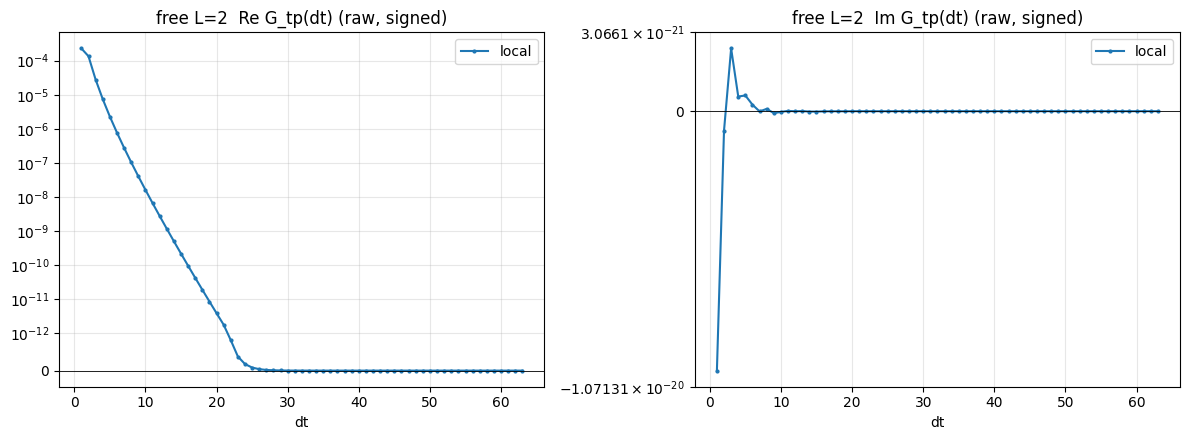

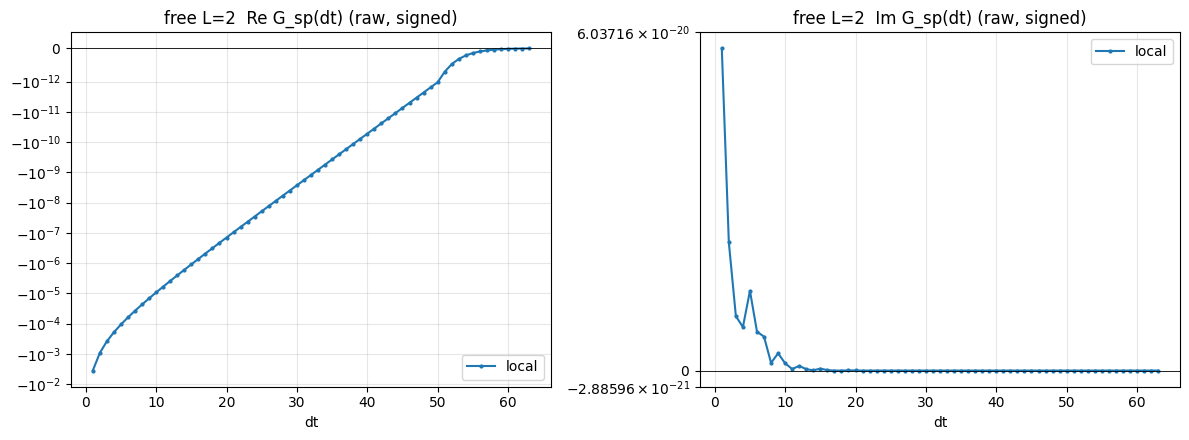

In [2]:
def plot_reim(proj, linthresh=1e-12):
    dd = np.arange(1, Nt//2)
    fig, ax = plt.subplots(1, 2, figsize=(12,4.5))
    for key,p in FILES.items():
        g = load_corr(p, proj)
        if g is None: continue
        ax[0].plot(dd, g[1:Nt//2].real, marker=".", ms=4, label=key)
        ax[1].plot(dd, g[1:Nt//2].imag, marker=".", ms=4, label=key)
    for a,t in zip(ax, [f"Re G_{proj}(dt)", f"Im G_{proj}(dt)"]):
        a.set_yscale("symlog", linthresh=linthresh)
        a.axhline(0, color="k", lw=.6)
        a.set_xlabel("dt"); a.set_title(f"free L={L}  {t} (raw, signed)")
        a.legend(); a.grid(alpha=.3, which="both")
    plt.tight_layout(); plt.show()

plot_reim("tp")
plot_reim("sp")

## Connected (plateau-subtracted) tp & sp shapes, normalized to $dt=1$
At L=2 only `local` is present (`exact`/`cont` absent).

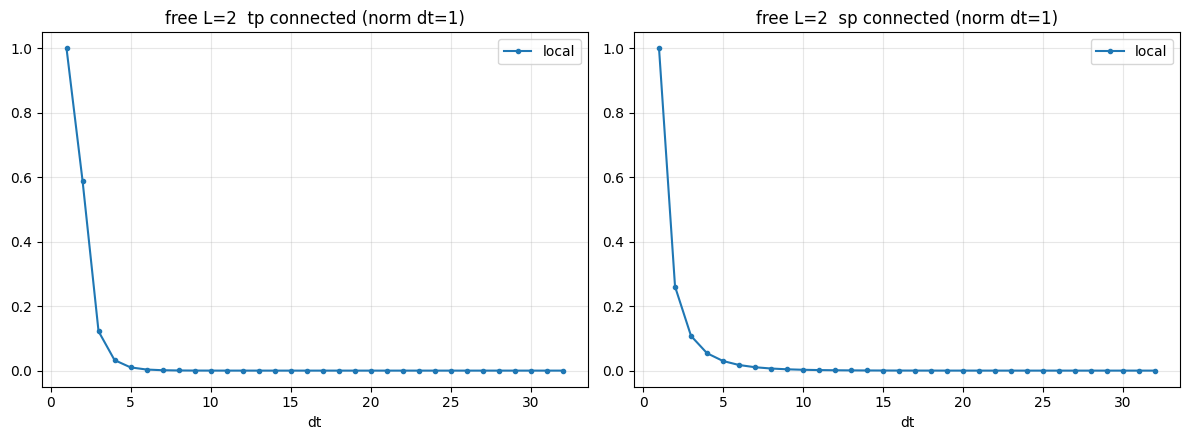

In [3]:
ds = np.arange(1,33)
fig,ax = plt.subplots(1,2,figsize=(12,4.5))
for key,p in FILES.items():
    ct = connected(load_corr(p,"tp"))
    if ct is not None:
        ax[0].plot(ds, (ct/ct[1]).real[ds], marker=".", label=key)
    cs = connected(load_corr(p,"sp"))
    if cs is not None:
        ax[1].plot(ds, (cs/cs[1]).real[ds], marker=".", label=key)
for a,t in zip(ax,["tp connected (norm dt=1)","sp connected (norm dt=1)"]):
    a.set_xlabel("dt"); a.set_title(f"free L={L}  {t}"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## $G_s/G_t$ ratio (local + lattice $P$)
CFT prediction: flat $-(D-1)=-2$.  (At L=2 the available method is `local`; sign is $-$ but magnitude not yet at $-2$.)

Gs/Gt dt=1..6: [-15.703, -6.943, -13.842, -25.977, -46.656, -80.898]


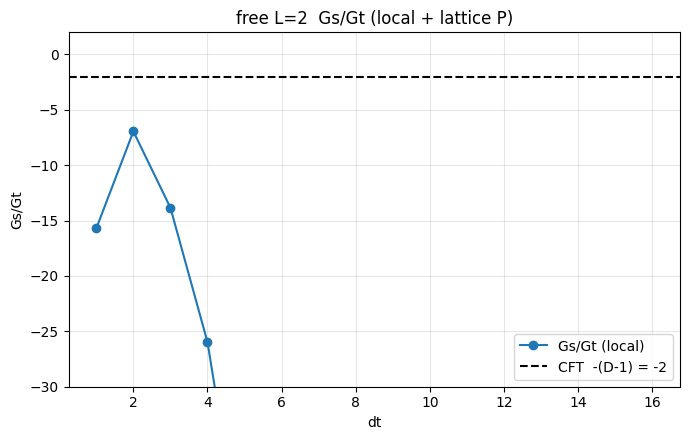

In [4]:
gt = connected(load_corr(FILES["local"],"tp"))
gs = connected(load_corr(FILES["local"],"sp"))
ds = np.arange(1,17)
plt.figure(figsize=(7,4.5))
if gt is not None and gs is not None:
    with np.errstate(divide="ignore",invalid="ignore"):
        r = (gs/gt).real
    plt.plot(ds, r[ds], marker="o", label="Gs/Gt (local)")
    print("Gs/Gt dt=1..6:", [round(float(r[d]),3) for d in range(1,7)])
plt.axhline(-2, color="k", ls="--", label="CFT  -(D-1) = -2")
plt.xlabel("dt"); plt.ylabel("Gs/Gt"); plt.title(f"free L={L}  Gs/Gt (local + lattice P)")
plt.ylim(-30,2); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()